In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import defaultdict

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


In [13]:
def safe_float(value, default=0.0):
    """
    安全地将字符串转换为浮点数，处理缺失值（'.' 或空字符串）
    """
    if not value or value == '.' or value.strip() == '':
        return default
    try:
        return float(value)
    except (ValueError, TypeError):
        return default

def parse_vcf_file(vcf_path):
    """
    解析VCF文件，提取OpenSpliceAI和PHENOTYPES信息
    返回DataFrame，包含：CHROM, POS, REF, ALT, DS_AG, DS_AL, DS_DG, DS_DL, PHENOTYPES
    """
    data = []
    
    with open(vcf_path, 'r') as f:
        for line in f:
            # 跳过注释行
            if line.startswith('#'):
                continue
            
            fields = line.strip().split('\t')
            if len(fields) < 8:
                continue
            
            chrom = fields[0]
            pos = fields[1]
            ref = fields[3]
            alt = fields[4]
            info = fields[7]
            
            # 解析INFO字段
            info_dict = {}
            for item in info.split(';'):
                if '=' in item:
                    key, value = item.split('=', 1)
                    info_dict[key] = value
            
            # 提取OpenSpliceAI信息
            openspliceai = info_dict.get('OpenSpliceAI', '')
            if openspliceai:
                parts = openspliceai.split('|')
                if len(parts) >= 6:  # 至少需要6个部分（ALLELE|SYMBOL|DS_AG|DS_AL|DS_DG|DS_DL）
                    ds_ag = safe_float(parts[2], 0.0)
                    ds_al = safe_float(parts[3], 0.0)
                    ds_dg = safe_float(parts[4], 0.0)
                    ds_dl = safe_float(parts[5], 0.0)
                else:
                    continue
            else:
                continue
            
            # 提取PHENOTYPES和CONSEQUENCE
            phenotypes = info_dict.get('PHENOTYPES', '')
            consequence = info_dict.get('CONSEQUENCE', '')
            
            # 创建唯一标识符
            variant_id = f"{chrom}:{pos}:{ref}>{alt}"
            
            data.append({
                'variant_id': variant_id,
                'CHROM': chrom,
                'POS': pos,
                'REF': ref,
                'ALT': alt,
                'DS_AG': ds_ag,
                'DS_AL': ds_al,
                'DS_DG': ds_dg,
                'DS_DL': ds_dl,
                'PHENOTYPES': phenotypes,
                'CONSEQUENCE': consequence
            })
    
    return pd.DataFrame(data)

# 读取两个VCF文件
print("读取limb VCF文件...")
df_limb = parse_vcf_file('/home1/xyf/data/openspliceai_tissue_data/variant/limb_400_train.vcf')
print(f"Limb文件包含 {len(df_limb)} 个变异")

print("\n读取neuron VCF文件...")
df_neuron = parse_vcf_file('/home1/xyf/data/openspliceai_tissue_data/variant/neuron_400_train.vcf')
print(f"Neuron文件包含 {len(df_neuron)} 个变异")


读取limb VCF文件...
Limb文件包含 4733 个变异

读取neuron VCF文件...
Neuron文件包含 4733 个变异


In [14]:
def classify_phenotype(phenotypes_str):
    """
    根据PHENOTYPES字符串分类
    返回: 'both', 'limbs_only', 'nervous_only', 'neither'
    """
    has_limbs = 'Abnormality_of_limbs' in phenotypes_str
    has_nervous = 'Abnormality_of_the_nervous_system' in phenotypes_str
    
    if has_limbs and has_nervous:
        return 'both'
    elif has_limbs:
        return 'limbs_only'
    elif has_nervous:
        return 'nervous_only'
    else:
        return 'neither'

# 为每个数据框添加phenotype分类
df_limb['phenotype_class'] = df_limb['PHENOTYPES'].apply(classify_phenotype)
df_neuron['phenotype_class'] = df_neuron['PHENOTYPES'].apply(classify_phenotype)

# 合并两个数据框，基于variant_id，包含CONSEQUENCE
df_merged = pd.merge(
    df_limb[['variant_id', 'DS_AG', 'DS_AL', 'DS_DG', 'DS_DL', 'phenotype_class', 'CONSEQUENCE']],
    df_neuron[['variant_id', 'DS_AG', 'DS_AL', 'DS_DG', 'DS_DL', 'phenotype_class']],
    on='variant_id',
    suffixes=('_limb', '_neuron'),
    how='inner'
)

# 合并phenotype_class（应该相同，取其中一个）
df_merged['phenotype_class'] = df_merged['phenotype_class_limb']

# 过滤只保留splice相关的变异
target_consequences = ['splice_donor_variant_Likely_LOF', 'splice_acceptor_variant_Likely_LOF']
df_merged_filtered = df_merged[df_merged['CONSEQUENCE'].isin(target_consequences)].copy()

print(f"合并后的数据包含 {len(df_merged)} 个共同的变异")
print(f"过滤后（只保留splice_donor_variant_Likely_LOF和splice_acceptor_variant_Likely_LOF）包含 {len(df_merged_filtered)} 个变异")
print("\nPhenotype分类统计（过滤后）:")
print(df_merged_filtered['phenotype_class'].value_counts())
print("\nCONSEQUENCE分类统计（过滤后）:")
print(df_merged_filtered['CONSEQUENCE'].value_counts())


合并后的数据包含 4733 个共同的变异
过滤后（只保留splice_donor_variant_Likely_LOF和splice_acceptor_variant_Likely_LOF）包含 243 个变异

Phenotype分类统计（过滤后）:
phenotype_class
nervous_only    138
both             83
neither          11
limbs_only       11
Name: count, dtype: int64

CONSEQUENCE分类统计（过滤后）:
CONSEQUENCE
splice_donor_variant_Likely_LOF       134
splice_acceptor_variant_Likely_LOF    109
Name: count, dtype: int64


In [15]:
# 验证数据完整性（使用过滤后的数据）
label_map_temp = {
    'both': 'Both (Limbs + Nervous)',
    'limbs_only': 'Limbs only',
    'nervous_only': 'Nervous system only',
    'neither': 'Neither'
}

print("=" * 60)
print("数据验证（过滤后：只包含splice相关变异）")
print("=" * 60)
print(f"过滤后的总变异数: {len(df_merged_filtered)}")
print(f"\n按Phenotype分类的变异数:")
for pclass in ['both', 'limbs_only', 'nervous_only', 'neither']:
    count = (df_merged_filtered['phenotype_class'] == pclass).sum()
    print(f"  {label_map_temp[pclass]}: {count}")

print(f"\n按CONSEQUENCE分类的变异数:")
print(df_merged_filtered['CONSEQUENCE'].value_counts())

# 检查是否有缺失值
print(f"\n缺失值检查:")
for ds in ['DS_AG', 'DS_AL', 'DS_DG', 'DS_DL']:
    missing_limb = df_merged_filtered[f'{ds}_limb'].isna().sum()
    missing_neuron = df_merged_filtered[f'{ds}_neuron'].isna().sum()
    print(f"  {ds}_limb: {missing_limb} 个缺失值")
    print(f"  {ds}_neuron: {missing_neuron} 个缺失值")

print(f"\n所有过滤后的变异都将被绘制在散点图中（共 {len(df_merged_filtered)} 个点）")

数据验证（过滤后：只包含splice相关变异）
过滤后的总变异数: 243

按Phenotype分类的变异数:
  Both (Limbs + Nervous): 83
  Limbs only: 11
  Nervous system only: 138
  Neither: 11

按CONSEQUENCE分类的变异数:
CONSEQUENCE
splice_donor_variant_Likely_LOF       134
splice_acceptor_variant_Likely_LOF    109
Name: count, dtype: int64

缺失值检查:
  DS_AG_limb: 0 个缺失值
  DS_AG_neuron: 0 个缺失值
  DS_AL_limb: 0 个缺失值
  DS_AL_neuron: 0 个缺失值
  DS_DG_limb: 0 个缺失值
  DS_DG_neuron: 0 个缺失值
  DS_DL_limb: 0 个缺失值
  DS_DL_neuron: 0 个缺失值

所有过滤后的变异都将被绘制在散点图中（共 243 个点）


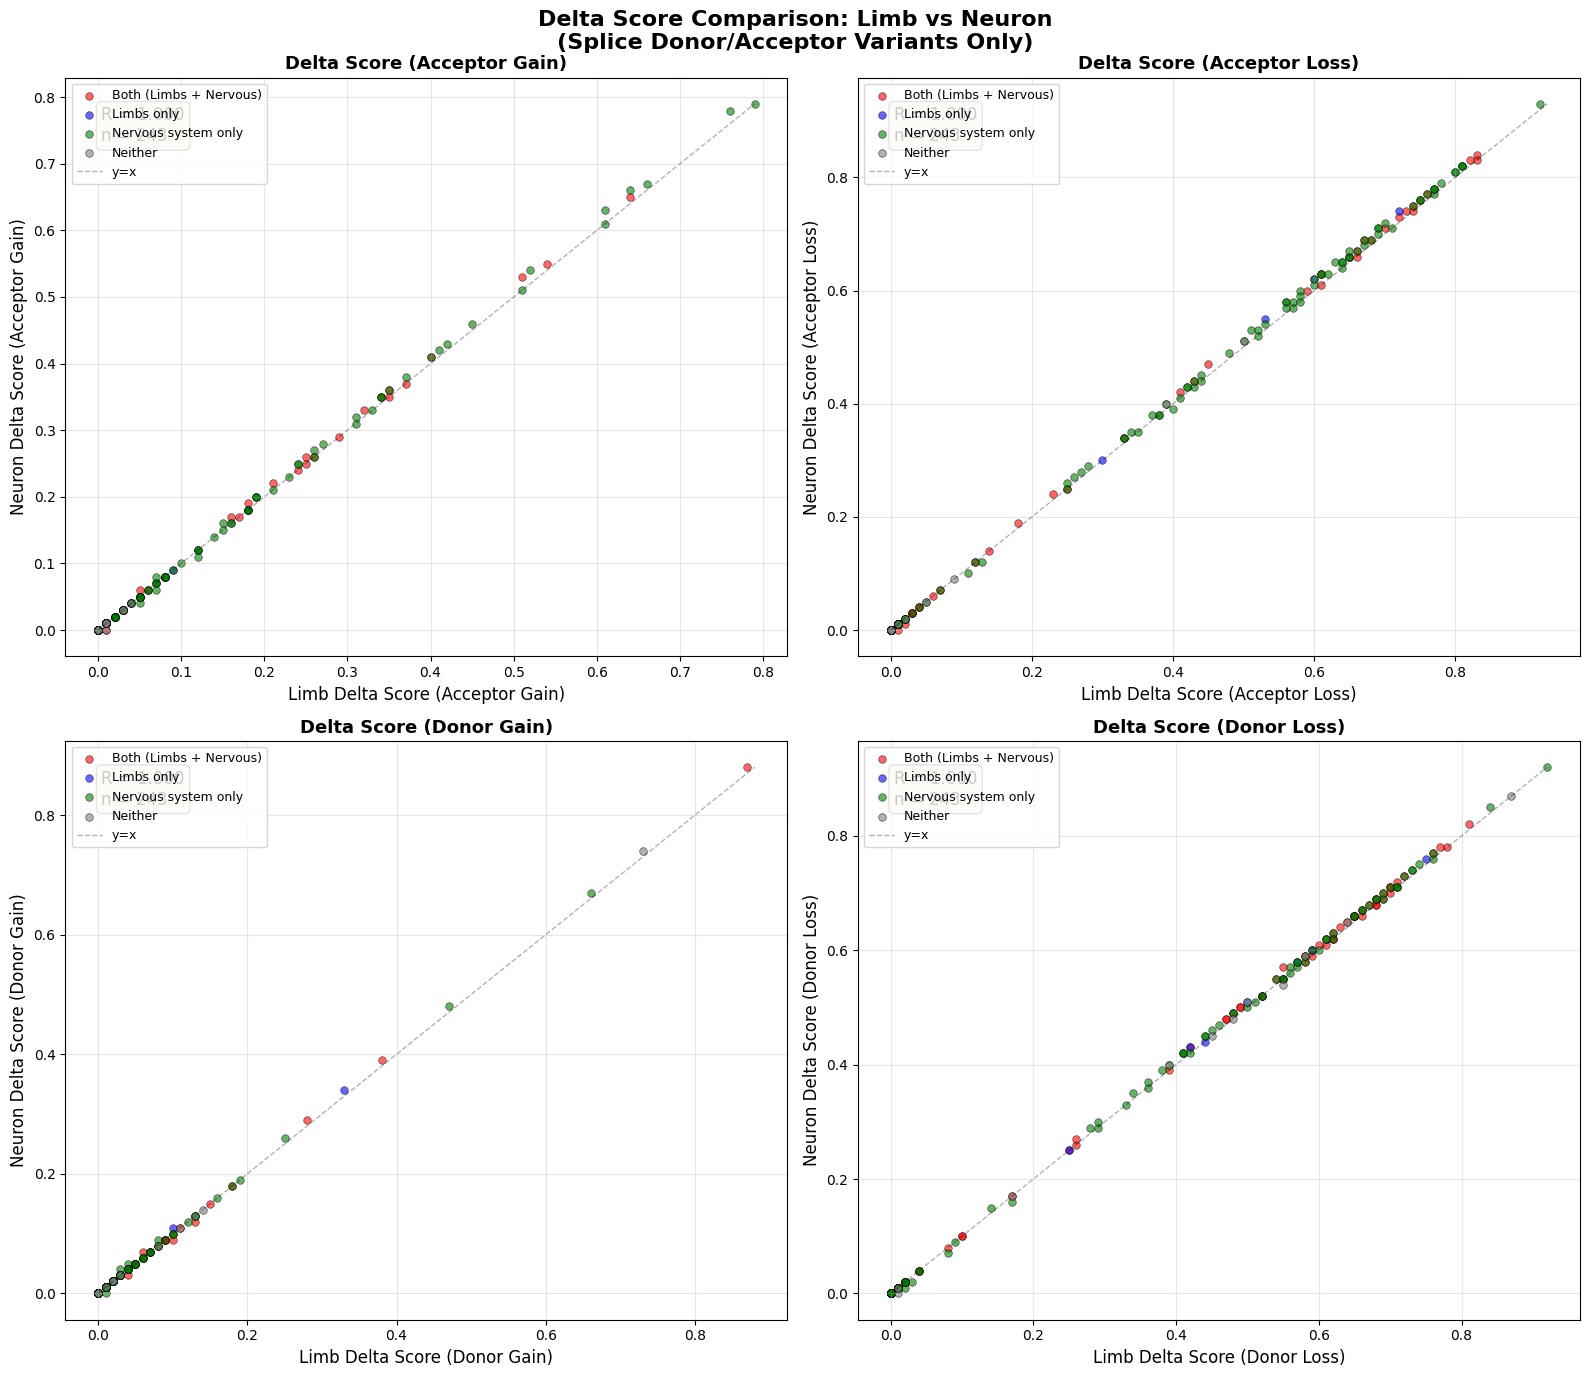

In [16]:
# 定义颜色映射
color_map = {
    'both': 'red',           # 两者都有 - 红色
    'limbs_only': 'blue',    # 只有limbs - 蓝色
    'nervous_only': 'green', # 只有nervous - 绿色
    'neither': 'gray'        # 两者都没有 - 灰色
}

label_map = {
    'both': 'Both (Limbs + Nervous)',
    'limbs_only': 'Limbs only',
    'nervous_only': 'Nervous system only',
    'neither': 'Neither'
}

# 创建4个子图，每个对应一个delta score类型（只显示splice相关变异）
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Delta Score Comparison: Limb vs Neuron\n(Splice Donor/Acceptor Variants Only)', fontsize=16, fontweight='bold')

delta_scores = ['DS_AG', 'DS_AL', 'DS_DG', 'DS_DL']
delta_names = [
    'Delta Score (Acceptor Gain)',
    'Delta Score (Acceptor Loss)',
    'Delta Score (Donor Gain)',
    'Delta Score (Donor Loss)'
]

for idx, (ds, ds_name) in enumerate(zip(delta_scores, delta_names)):
    ax = axes[idx // 2, idx % 2]
    
    # 为每个phenotype类别绘制散点图（使用过滤后的数据）
    for pclass in ['both', 'limbs_only', 'nervous_only', 'neither']:
        mask = df_merged_filtered['phenotype_class'] == pclass
        if mask.sum() > 0:
            ax.scatter(
                df_merged_filtered.loc[mask, f'{ds}_limb'],
                df_merged_filtered.loc[mask, f'{ds}_neuron'],
                c=color_map[pclass],
                label=label_map[pclass],
                alpha=0.6,
                s=30,
                edgecolors='black',
                linewidths=0.5
            )
    
    # 添加对角线（y=x）
    min_val = min(df_merged_filtered[f'{ds}_limb'].min(), df_merged_filtered[f'{ds}_neuron'].min())
    max_val = max(df_merged_filtered[f'{ds}_limb'].max(), df_merged_filtered[f'{ds}_neuron'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, linewidth=1, label='y=x')
    
    # 计算相关系数
    corr = df_merged_filtered[f'{ds}_limb'].corr(df_merged_filtered[f'{ds}_neuron'])
    ax.text(0.05, 0.95, f'R = {corr:.3f}\nn = {len(df_merged_filtered)}', transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel(f'Limb {ds_name}', fontsize=12)
    ax.set_ylabel(f'Neuron {ds_name}', fontsize=12)
    ax.set_title(ds_name, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()


In [17]:
# 打印一些统计信息（使用过滤后的数据）
print("=" * 60)
print("Delta Score 统计摘要（Splice相关变异）")
print("=" * 60)

for ds, ds_name in zip(delta_scores, delta_names):
    print(f"\n{ds_name}:")
    print(f"  Limb - Mean: {df_merged_filtered[f'{ds}_limb'].mean():.4f}, Std: {df_merged_filtered[f'{ds}_limb'].std():.4f}")
    print(f"  Neuron - Mean: {df_merged_filtered[f'{ds}_neuron'].mean():.4f}, Std: {df_merged_filtered[f'{ds}_neuron'].std():.4f}")
    print(f"  相关系数: {df_merged_filtered[f'{ds}_limb'].corr(df_merged_filtered[f'{ds}_neuron']):.4f}")
    print(f"  平均差异: {(df_merged_filtered[f'{ds}_limb'] - df_merged_filtered[f'{ds}_neuron']).mean():.4f}")
    print(f"  绝对平均差异: {(df_merged_filtered[f'{ds}_limb'] - df_merged_filtered[f'{ds}_neuron']).abs().mean():.4f}")

print("\n" + "=" * 60)
print("按Phenotype分类的变异数量:")
print(df_merged_filtered['phenotype_class'].value_counts())
print("\n按CONSEQUENCE分类的变异数量:")
print(df_merged_filtered['CONSEQUENCE'].value_counts())


Delta Score 统计摘要（Splice相关变异）

Delta Score (Acceptor Gain):
  Limb - Mean: 0.0926, Std: 0.1564
  Neuron - Mean: 0.0941, Std: 0.1595
  相关系数: 0.9998
  平均差异: -0.0014
  绝对平均差异: 0.0019

Delta Score (Acceptor Loss):
  Limb - Mean: 0.2498, Std: 0.3002
  Neuron - Mean: 0.2537, Std: 0.3052
  相关系数: 0.9999
  平均差异: -0.0040
  绝对平均差异: 0.0044

Delta Score (Donor Gain):
  Limb - Mean: 0.0443, Std: 0.0997
  Neuron - Mean: 0.0447, Std: 0.1013
  相关系数: 0.9998
  平均差异: -0.0004
  绝对平均差异: 0.0007

Delta Score (Donor Loss):
  Limb - Mean: 0.3024, Std: 0.2973
  Neuron - Mean: 0.3056, Std: 0.3005
  相关系数: 0.9999
  平均差异: -0.0031
  绝对平均差异: 0.0036

按Phenotype分类的变异数量:
phenotype_class
nervous_only    138
both             83
neither          11
limbs_only       11
Name: count, dtype: int64

按CONSEQUENCE分类的变异数量:
CONSEQUENCE
splice_donor_variant_Likely_LOF       134
splice_acceptor_variant_Likely_LOF    109
Name: count, dtype: int64
